A straightforward and easily interpretable visualization technique, a Class Activation Map (CAM) 
will allow me to view and better understand what features the model is using to make its predictions. This first model is a proof of concept, and I still need to determine if my data set is large enough, and if I'm using the right model architecture.

In [1]:
from fastai.vision.all import *

path = Path('/Users/ossie/sdhnet/data/animals/imagenette2-160/')

lbl_dict = dict(
    n01440764='tench',
    n02102040='English springer',
    n02979186='cassette player',
    n03000684='chain saw',
    n03028079='church',
    n03394916='French horn',
    n03417042='garbage truck',
    n03425413='gas pump',
    n03445777='golf ball',
    n03888257='parachute',
    birds='bird'
)

def label_func(fname):
  return lbl_dict[parent_label(fname)]

def get_lr(learner):
    lr_min, lr_steep = learner.lr_find(suggest_funcs=(minimum, steep))
    res = round( ( (lr_min + lr_steep)/2 ), 5)
    print('Learning rate finder result: ', res)
    return res

def find_last_conv3(learner):
    modules = list(learner.modules())
    for module in reversed(modules):
        if hasattr(module, 'conv3'):
            conv3_out = module.conv3.out_channels
            print(f'Found: {conv3_out}')
            return module.conv3
    return None

'''
For information on the various types of color maps available,
See the docs: https://matplotlib.org/stable/users/explain/colors/colormaps.html
'''
def show_cam(x, cam_map, cmap):
    x_dec = TensorImage(dls.train.decode((x,))[0][0])
    _, ax = plt.subplots()
    x_dec.show(ctx=ax)
    ax.imshow(cam_map[1].detach().cpu(), alpha=0.6, extent=(0,128,128,0),
              interpolation='bilinear', cmap=cmap)

'''
A class to define the forward pass hook
m = module or layer the to which the hook is attached
i = input to the layer
o = output from the layer
'''
import pprint
class Hook():
    def __init__(self, learner):
        self.learner = learner
        
    def hook_func(self, m: nn.Module, i: Tensor, o: Tensor):
        self.stored = o.detach().clone()
        
    def get_activations(self, x):
        # Attach hook, get predictions
        last_conv3 = find_last_conv3(learner.model)
        hook = last_conv3.register_forward_hook(self.hook_func)
        #hook = learner.model[0].register_forward_hook(self.hook_func)
        with torch.no_grad(): output = learner.model.eval()(x)

        # Print out a list of classes and predicted probabilities
        preds = F.softmax(output, dim=-1).tolist()[0]
        predicted_labels = {dls.vocab[i]: round(prob, 3) for i, prob in enumerate(preds)}
        pprint.pprint(predicted_labels)

        # The first tensor are the activations
        return self.stored[0]

/Users/ossie/anaconda3/envs/fastbook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First, let's create a datablock and train our model.

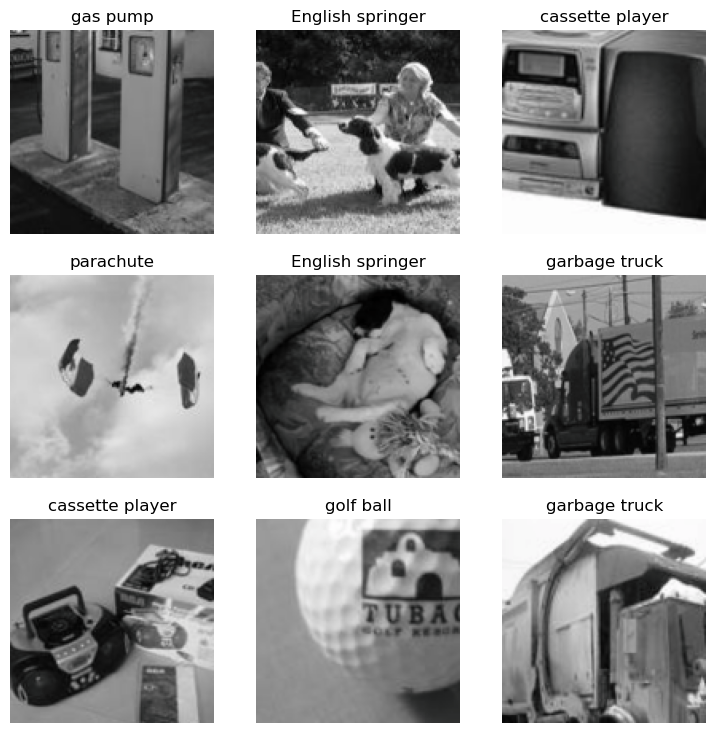

In [2]:
dblock = DataBlock(blocks = (ImageBlock(cls=PILImageBW), CategoryBlock),
                   get_items = get_image_files, get_y = label_func,
                   splitter = GrandparentSplitter(),
                   item_tfms = RandomResizedCrop(128, min_scale=0.35),
                   batch_tfms = Normalize.from_stats(*imagenet_stats))
dls = dblock.dataloaders(path, batch_size=64)
dls.show_batch()

In [3]:
learner = vision_learner(dls, resnet50, metrics=[accuracy, F1Score(average='micro')], pretrained=False)
# lr = get_lr(learner)

The two images used for the CAM were taken from google images, and have not been seen before by the model. Both images are relatively simple, with some but not too many potentially distracting objects in the images.

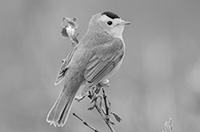

In [4]:
img_bird = PILImage.create('/Users/ossie/sdhnet/birdie.jpg').convert('L')
display(img_bird)

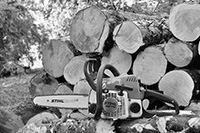

In [5]:
img_chainsaw = PILImage.create('/Users/ossie/sdhnet/chainsaw.jpg').convert('L')
display(img_chainsaw)

In [14]:
x_bird, = first(dls.test_dl([img_bird]))
x_chainsaw, = first(dls.test_dl([img_chainsaw]))

In [15]:
last_conv3 = find_last_conv3(learner.model)

Found: 2048


In [30]:
callback = [EarlyStoppingCallback(monitor='train_loss', min_delta=0.1, patience=4)]
learner.fit_one_cycle(20, lr, cbs=callback)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.864713,2.280389,0.226621,0.226621,01:02
1,2.511195,2.032847,0.313821,0.313821,01:01
2,2.296572,1.952552,0.378674,0.378674,01:03
3,2.062143,3.783626,0.153267,0.153267,01:03
4,2.286076,2.686876,0.161525,0.161525,01:02
5,2.341213,2.207037,0.290989,0.290989,01:01
6,2.162627,2.167389,0.284430,0.284430,01:00
7,1.904076,1.713643,0.435511,0.435511,01:00
8,1.931010,2.447348,0.216177,0.216177,01:02
9,1.701491,1.953045,0.497935,0.497935,01:02


In [82]:
torch.save(learner.model.state_dict(), 'model_weights.pth')

In [17]:
learner.model.load_state_dict(torch.load('model_weights.pth'))

<All keys matched successfully>

In [19]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)

mps


In [20]:
learner.model.to(device)

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64, 256

In [28]:
x_bird = x_bird.to(device)
print(x_bird.shape)

torch.Size([1, 3, 128, 128])


Found: 2048


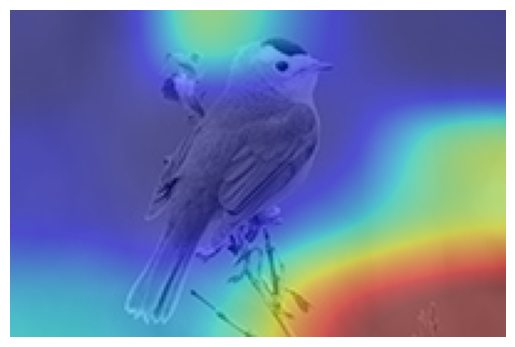

In [31]:
# Grad-CAM
import torchcam
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

learner.model.eval()
extractor = SmoothGradCAMpp(learner.model, find_last_conv3(learner))
with torch.enable_grad():
    out = learner.model(x_bird)
    class_idx = out.argmax().item()
    activation_map = extractor(class_idx, out)

result = overlay_mask(img_bird.convert('RGB'), to_pil_image(activation_map[0], mode='F'), alpha=0.5)
plt.imshow(result)
plt.axis('off')
plt.show()

In [74]:
hook = Hook(learner) 
cam_map = torch.einsum('ck,kij->cij', learner.model[1][-1].weight, hook.get_activations(x_bird))
show_cam(x_bird, cam_map, 'inferno')

Found: 2048
{'English springer': 0.002,
 'French horn': 0.007,
 'bird': 0.665,
 'cassette player': 0.001,
 'chain saw': 0.003,
 'church': 0.043,
 'garbage truck': 0.0,
 'gas pump': 0.001,
 'golf ball': 0.039,
 'parachute': 0.236,
 'tench': 0.002}


RuntimeError: einsum(): the number of subscripts in the equation (2) does not match the number of dimensions (4) for operand 0 and no ellipsis was given

The read areas in the 'coolwarm' colormap identify areas that had a strong influence in classfiying the image. The blue areas represent low activation areas that may be unimportant or even sway classification away from the target category. In this example, we can see a heavy weight towards the shape and outline of the bird's feathers. Surprisingly, the head is not weighed heavily. In terms of shape, it may not be very distinct from shapes seen in other classes.

{'English springer': 0.001,
 'French horn': 0.005,
 'bird': 0.013,
 'cassette player': 0.0,
 'chain saw': 0.945,
 'church': 0.013,
 'garbage truck': 0.008,
 'gas pump': 0.0,
 'golf ball': 0.001,
 'parachute': 0.012,
 'tench': 0.0}


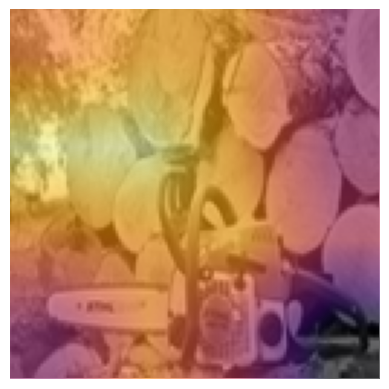

In [28]:
cam_map = torch.einsum('ck,kij->cij', learner.model[1][-1].weight, hook.get_activations(x_chainsaw))
show_cam(x_chainsaw, cam_map, 'inferno')

The chainsaw CAM seems to show the model relying more on the tip of the blade or even handle area of the chainsaw.

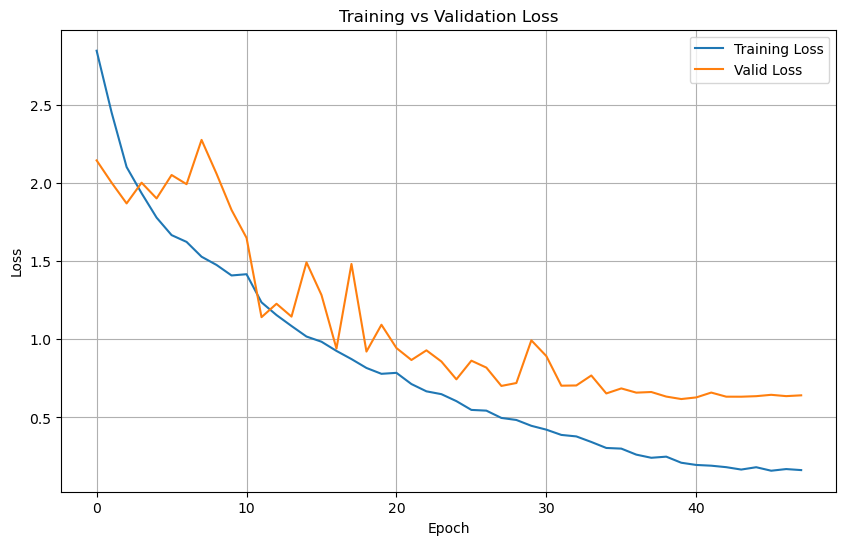

In [17]:
import matplotlib.pyplot as plt

epochs = range(48)
train_loss = [
    2.844347, 2.449085, 2.100685, 1.933238, 1.777271, 1.665475, 1.622008, 1.527297,
    1.474663, 1.407493, 1.415421, 1.235469, 1.154258, 1.084406, 1.016966, 0.983838,
    0.925025, 0.872876, 0.816097, 0.778634, 0.784889, 0.713234, 0.666678, 0.648547,
    0.604048, 0.547879, 0.543233, 0.496615, 0.483592, 0.446265, 0.421635, 0.388011,
    0.378439, 0.342902, 0.304568, 0.300446, 0.262019, 0.241830, 0.249012, 0.210160,
    0.195974, 0.191287, 0.181806, 0.166535, 0.181457, 0.159087, 0.169669, 0.163086
]

valid_loss = [
    2.143126, 2.000618, 1.868072, 2.000670, 1.900026, 2.049788, 1.991050, 2.274224,
    2.057649, 1.826273, 1.647936, 1.140924, 1.226497, 1.144427, 1.491479, 1.282438,
    0.939886, 1.481266, 0.920881, 1.092368, 0.943482, 0.866987, 0.928763, 0.857259,
    0.743349, 0.862629, 0.818368, 0.701186, 0.719802, 0.992651, 0.891964, 0.702693,
    0.704190, 0.767950, 0.653094, 0.685281, 0.658318, 0.662346, 0.633076, 0.617365,
    0.627751, 0.658778, 0.632480, 0.632282, 0.635682, 0.644417, 0.636011, 0.641095
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, valid_loss, label='Valid Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()